In [1]:
%matplotlib inline

import lasio
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# PARÁMETROS AJUSTABLES
LAS_DIR = Path("./data/cuencas_force-norway")   # Carpeta con los archivos .las
OUTPUT_DIR = Path("./output/pairplots")         # Carpeta de salida
MAX_FILES = 10                                # Límite de archivos a escalar después
NULL_VALUE = -9999.25                         # Valor nulo estándar LAS
MIN_VARIABLES = 2                             # Mínimo de curvas válidas por archivo
NAN_THRESH = 0.5                              # Máximo de NaN permitido por columna

print(f"Archivos encontrados: {len(list(LAS_DIR.glob('*.las')))}")

Archivos encontrados: 118


In [2]:

# Acumulador global de mensajes para el reporte
LOG_LINES = []

def log(msg: str = ""):
    """
    Imprime msg en pantalla y además lo guarda en LOG_LINES.
    Usa log(...) en lugar de print(...) para los mensajes de reporte.
    """
    print(msg)
    LOG_LINES.append(msg)


def save_full_report_to_txt(
    stats_per_well: dict,
    stats_global: pd.DataFrame,
    output_dir: Path,
    filename: str = "reporte_completo_LAS.txt",
) -> Path:
    """
    Guarda en un .txt:
    1) Todo el log acumulado (Archivos, columnas eliminadas, etc.)
    2) Tabla estadística global.
    3) Tablas estadísticas individuales por pozo.
    """
    output_dir.mkdir(parents=True, exist_ok=True)
    txt_path = output_dir / filename

    with open(txt_path, "w", encoding="utf-8") as f:
        # Sección 1: log textual
        f.write("### LOG DE PROCESAMIENTO\n")
        f.write("=" * 80 + "\n\n")
        for line in LOG_LINES:
            f.write(line + "\n")

        # Sección 2: tabla global
        f.write("\n\n### TABLA ESTADÍSTICA GLOBAL\n")
        f.write("=" * 80 + "\n\n")
        f.write(stats_global.to_string(index=False))
        f.write("\n\n")

        # Sección 3: tablas por pozo
        f.write("### TABLAS ESTADÍSTICAS POR POZO\n")
        f.write("=" * 80 + "\n\n")
        for name, df_stats in stats_per_well.items():
            f.write(f"--- POZO / REGISTRO: {name}\n")
            f.write(df_stats.to_string(index=False))
            f.write("\n\n")

    print(f"Reporte completo guardado en: {txt_path}")
    return txt_path

In [3]:
def load_las_files(las_dir: Path, max_files: int, null_value: float) -> dict:
    """
    Lee hasta maxfiles archivos .las.
    Retorna dict: {nombre_archivo_sin_ext: DataFrame crudo con DEPTH como columna normal}.
    """
    las_files = sorted(las_dir.glob("*.las"))[:max_files]

    if not las_files:
        raise FileNotFoundError(f"No se encontraron archivos .las en {las_dir}")

    raw_dfs = {}

    log(f"{'Archivo':<15} {'Filas':>8} {'Columnas':>8}")
    log("-" * 55)

    for path in las_files:
        try:
            las = lasio.read(str(path))
            df = las.df().reset_index()          # DEPTH pasa a ser columna normal
            df.replace(null_value, np.nan, inplace=True)
            raw_dfs[path.stem] = df
            log(f"{path.name:<15} {df.shape[0]:>8} {df.shape[1]:>8}")
        except Exception as e:
            log(f"{path.name:<15} ERROR al leer: {e}")

    log(f"\nTotal cargados: {len(raw_dfs):2d} / {len(las_files)} archivos")

    return raw_dfs


def filter_and_standardize(raw_dfs: dict, min_vars: int, nan_thresh: float):
    """
    Etapas:
    1. Descarta DataFrames con menos de minvars columnas numéricas.
    2. Elimina columnas con proporción de NaN > nanthresh.
    3. Calcula la intersección de columnas comunes a todos los DFs.
    4. Recorta cada DF a esas columnas y elimina filas con NaN residuales.
    5. Emite reporte de consistencia de filas.

    Retorna: (dict estandarizado, lista columnas_comunes)
    """
    # 1. Filtrar por mínimo de variables
    filtered = {}
    for name, df in raw_dfs.items():
        numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
        if len(numeric_cols) >= min_vars:
            filtered[name] = df[numeric_cols]
        else:
            log(f"{name!r} descartado: solo {len(numeric_cols)} variables numéricas.")

    if not filtered:
        raise ValueError("Ningún archivo pasó el filtro mínimo de variables.")

    # 2. Eliminar columnas con demasiados NaN
    cleaned = {}
    for name, df in filtered.items():
        nan_ratio = df.isna().mean()
        cols_keep = nan_ratio[nan_ratio <= nan_thresh].index.tolist()
        cols_dropped = nan_ratio[nan_ratio > nan_thresh].index.tolist()
        if cols_dropped:
            log(f"{name!r} — columnas eliminadas (>{nan_thresh*100:.0f}% NaN): {cols_dropped}")
        cleaned[name] = df[cols_keep]

    # 3. Intersección de columnas comunes
    common_cols = set(next(iter(cleaned.values())).columns)
    for df in cleaned.values():
        common_cols &= set(df.columns)
    common_cols = sorted(common_cols)

    if len(common_cols) < 2:
        raise ValueError(
            f"Solo {len(common_cols)} columnas en común entre todos los archivos. "
            "Considera reducir MINVARIABLES o revisar los mnemonics de tus curvas."
        )

    log(f"\nColumnas comunes detectadas: {len(common_cols)} {common_cols}\n")

    # 4 y 5. Recortar y reporte de filas
    standardized = {}

    log(f"{'Archivo':<15} {'Filas brutas':>12} {'Filas con NaN':>12} {'Filas finales':>12}")
    log("-" * 78)

    for name, df in cleaned.items():
        df_common = df[common_cols]
        rows_raw = len(df_common)
        nan_rows = int(df_common.isna().any(axis=1).sum())
        df_clean = df_common.dropna().reset_index(drop=True)
        rows_final = len(df_clean)

        log(f"{name:<15} {rows_raw:>12} {nan_rows:>12} {rows_final:>12}")

        if rows_final == 0:
            log(f"{name!r} sin filas válidas tras limpieza, omitido.")
            continue

        standardized[name] = df_clean

    log(f"\nArchivos listos para graficar: {len(standardized)}\n")

    return standardized, common_cols

In [4]:
def plot_pairplots_std_dfs(std_dfs: dict, output_dir: Path = None):
    """
    Genera, muestra dentro del notebook y guarda un pairplot por cada DataFrame estandarizado.
    """
    output_dir.mkdir(parents=True, exist_ok=True)
    total = len(std_dfs)

    for i, (name, df) in enumerate(std_dfs.items(), start=1):
        n_vars = df.shape[1]
        n_rows = df.shape[0]

        print(f"{i:>3}/{total} Generando pairplot {name}")
        print(f"{n_rows} muestras, {n_vars} variables")

        g = sns.pairplot(
            df,
            diag_kind="kde",
            kind="scatter",
            plot_kws={"alpha": 0.35, "s": 8, "edgecolors": "none"},
            diag_kws={"fill": True},
            height=2.0,
            aspect=1.0,
            corner=False,
        )

        g.figure.suptitle(f"{name} — {n_rows} muestras, {n_vars} variables",
                          y=1.02, fontsize=11, fontweight="bold")

        savepath = output_dir / f"pairplot_{name}.png"
        g.figure.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Guardado {save_path}")

        plt.show()
        plt.close("all")

    print(f"{total} pairplots generados en {output_dir}")


def compute_stats_per_well(std_dfs: dict, output_dir: Path) -> dict:
    """
    Calcula describe() para cada pozo y guarda CSV individuales.
    Retorna dict nombre -> DataFrame stats.
    """
    output_dir.mkdir(parents=True, exist_ok=True)
    stats_per_well = {}

    for name, df in std_dfs.items():
        stats = df.describe().T.reset_index().rename(columns={"index": "CURVE"})
        stats_per_well[name] = stats
        stats.to_csv(output_dir / f"stats_{name}.csv", index=False)

    return stats_per_well


def compute_global_stats(std_dfs: dict, common_cols: list, output_dir: Path) -> pd.DataFrame:
    """
    Concatena todos los DFs estandarizados y calcula describe() global.
    Guarda CSV global.
    """
    output_dir.mkdir(parents=True, exist_ok=True)
    all_df = pd.concat(std_dfs.values(), axis=0, ignore_index=True)
    stats_global = all_df[common_cols].describe().T.reset_index().rename(columns={"index": "CURVE"})
    stats_global.to_csv(output_dir / "stats_global.csv", index=False)
    return stats_global

Archivo            Filas Columnas
-------------------------------------------------------
15_9-13.las        21441       21
15_9-14.las        22875       21
15_9-15.las        20954       23
15_9-17.las        19879       22
15_9-23.las        20494       21
16_1-2.las         18547       20
16_1-6 A.las       13513       18
16_10-1.las        20147       23
16_10-2.las        20131       20
16_10-3.las        17995       23

Total cargados: 10 / 10 archivos
'15_9-13' — columnas eliminadas (>50% NaN): ['RSHA', 'RXO']
'15_9-14' — columnas eliminadas (>50% NaN): ['RSHA', 'RXO']
'16_1-2' — columnas eliminadas (>50% NaN): ['FORCE_2020_LITHOFACIES_CONFIDENCE', 'FORCE_2020_LITHOFACIES_LITHOLOGY', 'CALI', 'BS', 'NPHI', 'RHOB', 'DRHO']
'16_1-6 A' — columnas eliminadas (>50% NaN): ['FORCE_2020_LITHOFACIES_CONFIDENCE', 'FORCE_2020_LITHOFACIES_LITHOLOGY', 'CALI', 'DTC', 'NPHI', 'PEF', 'RHOB']
'16_10-1' — columnas eliminadas (>50% NaN): ['RSHA', 'RXO']
'16_10-2' — columnas eliminadas (>50% NaN): 

NameError: name 'save_path' is not defined

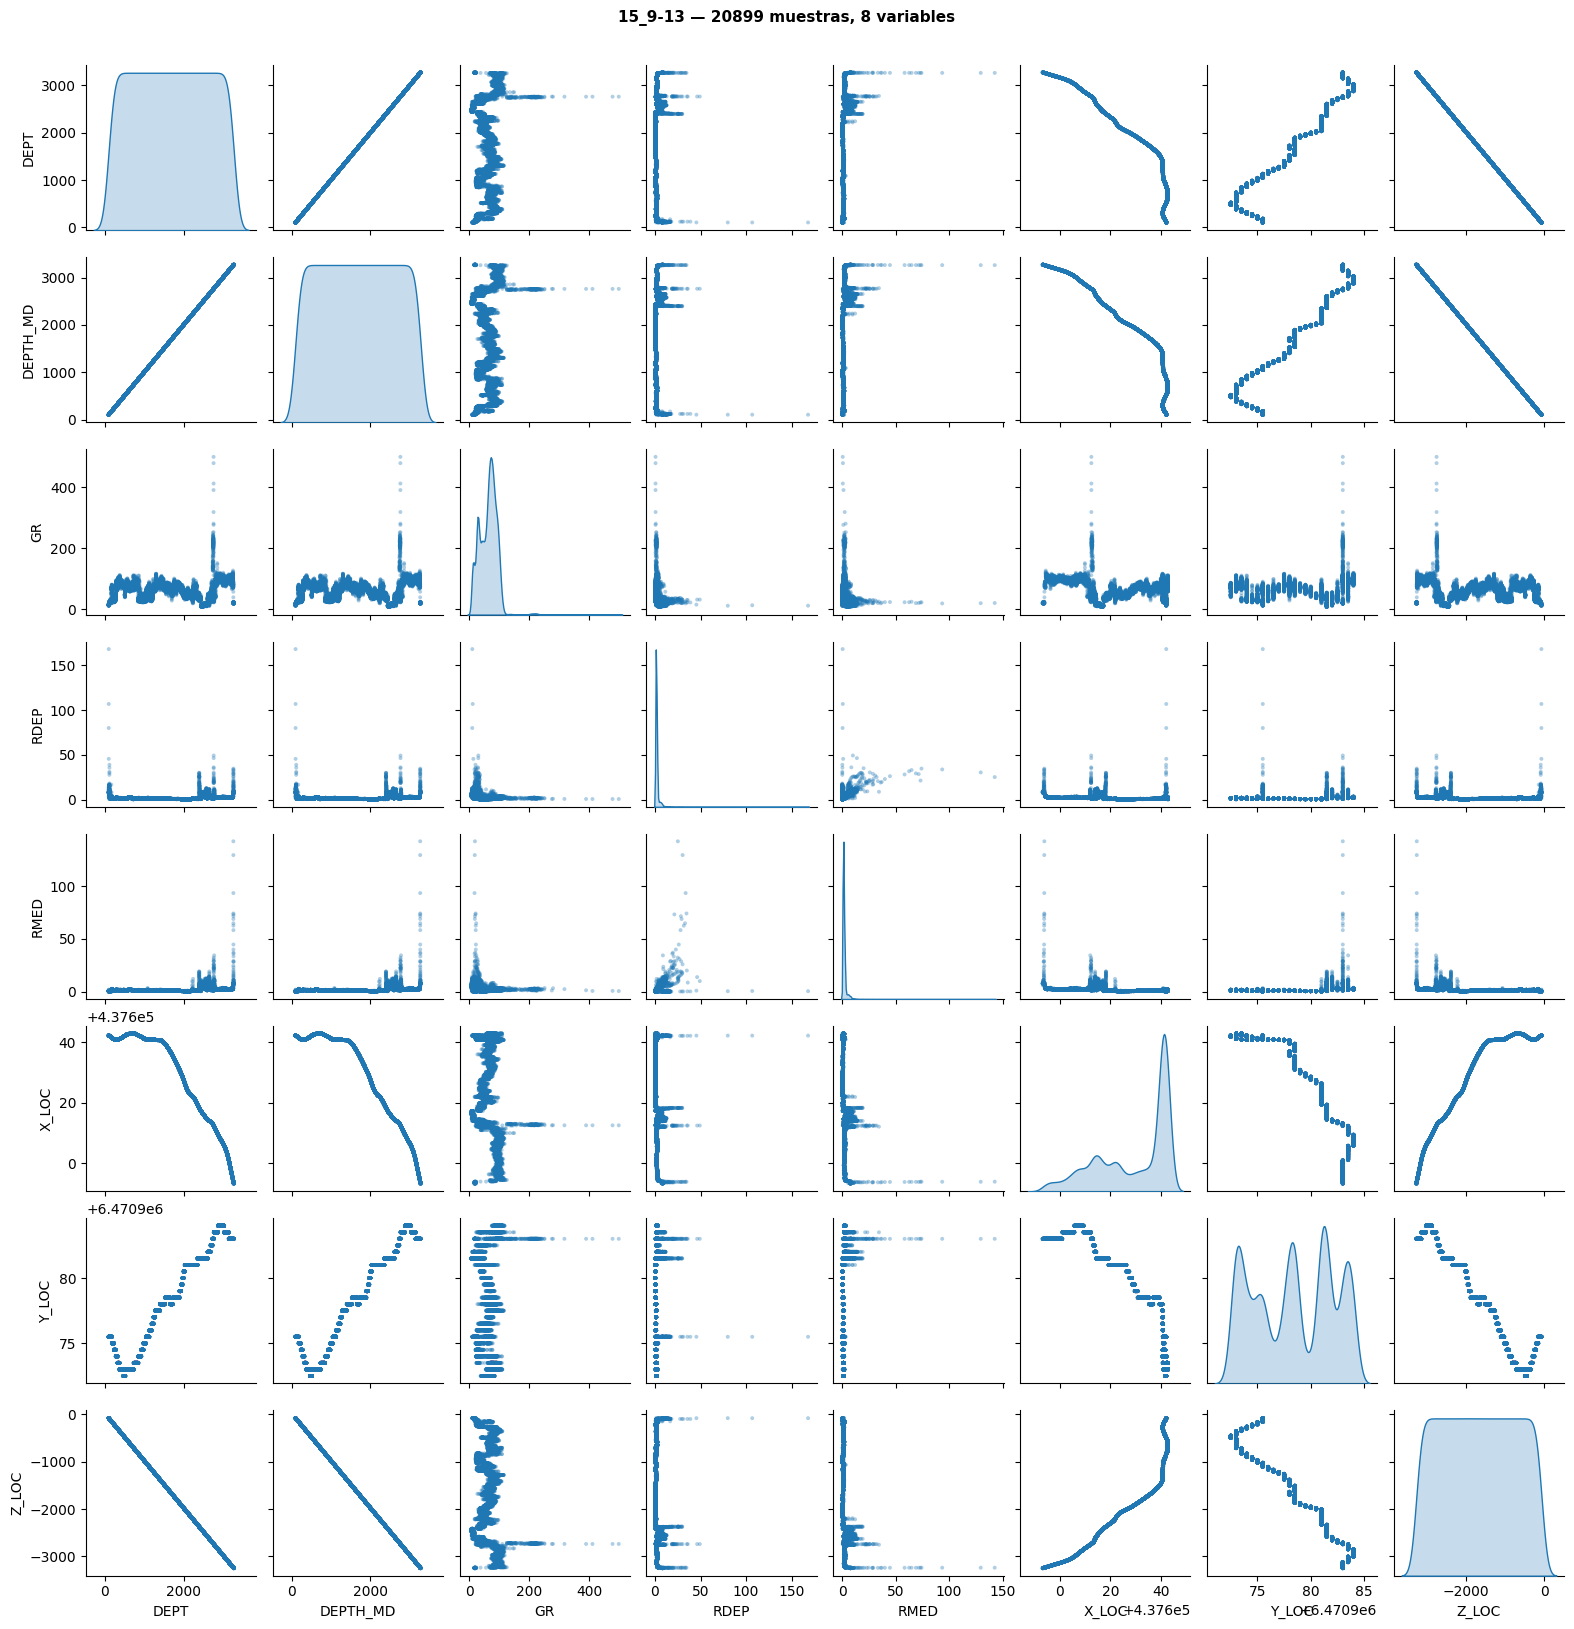

In [5]:
# ============================================
# CELDA 6: PIPELINE PRINCIPAL — ejecuta todo
# ============================================

# Limpiar log para esta ejecución
LOG_LINES.clear()

# ETAPA 1: Carga
raw_dfs = load_las_files(
    las_dir=LAS_DIR,
    max_files=MAX_FILES,
    null_value=NULL_VALUE,
)

# ETAPA 2: Filtrado y estandarización
std_dfs, common_cols = filter_and_standardize(
    raw_dfs=raw_dfs,
    min_vars=MIN_VARIABLES,
    nan_thresh=NAN_THRESH,
)

# ETAPA 3: Pairplots individuales
plot_pairplots_std_dfs(
    std_dfs=std_dfs,
    output_dir=OUTPUT_DIR,
)

# ETAPA 4: Estadísticas por pozo
stats_per_well = compute_stats_per_well(
    std_dfs=std_dfs,
    output_dir=OUTPUT_DIR,
)

# ETAPA 5: Estadísticas globales
stats_global = compute_global_stats(
    std_dfs=std_dfs,
    common_cols=common_cols,
    output_dir=OUTPUT_DIR,
)

# ETAPA 6: Guardar TODO en un .txt
save_full_report_to_txt(
    stats_per_well=stats_per_well,
    stats_global=stats_global,   # o stats_global_fmt si usas una versión resumida
    output_dir=OUTPUT_DIR,
)